In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
import jax
import ml_confs
import xarray as xr

from spectraformer.input_pipeline import preprocess_dataset, preprocess_dataset_raw

jax.config.update("jax_debug_nans", True)

# maindir = Path('/home/dpoteryayev/SpectraFormer/Poisson check.ipynb').parent.resolve()
maindir = Path("/mnt/c/Users/dpoteryayev/1. PhD/SpectraFormer/GammaCheck.ipynb").parent.resolve()

logdir = maindir / "logs"
ckptdir = maindir / "checkpoints"
# Check if logdir and ckptdir exist, if not create them
logdir.mkdir(parents=True, exist_ok=True)
ckptdir.mkdir(parents=True, exist_ok=True)

datadir = maindir / "data"

model_tag = "min8"  # CHOOSE ONE (.yaml file should exist)
                    # tag also can be found for already trained models in checkpoints folder

configsdir = maindir / "configs"
configsdir.mkdir(parents=True, exist_ok=True)

config_file_name = f"configs_{model_tag}.yaml"
config_file_path = configsdir / config_file_name

configs = ml_confs.from_file(config_file_path)
configs.tabulate()

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Key                    ┃ Value              ┃ Type      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ tag                    │ spectraformer:min8 │ str       │
│ embedding_dim          │ 64                 │ int       │
│ num_heads              │ 8                  │ int       │
│ num_layers             │ 2                  │ int       │
│ learning_rate          │ 0.0001             │ float     │
│ num_epochs             │ 600                │ int       │
│ batch_size             │ 19                 │ int       │
│ dropout_rate           │ 0.5                │ float     │
│ root_rng_seed          │ 0                  │ int       │
│ train_dataset          │ SiC_19x10x3        │ str       │
│ log_every_epochs       │ 5                  │ int       │
│ masked_interval_starts │ [1000, 2500]       │ list[int] │
│ masked_interval_ends   │ [1700, 2900]       │ list[int] │
└────────────────────────┴────────────────────┴───────────┘

In [3]:
# Load the full dataset
full_ds = preprocess_dataset(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc")
) - 0.1

mean_values = full_ds.mean(
    dim=['spectra']
)

variance_values = full_ds.var(
    dim=['spectra']
)

std_values = full_ds.std(
    dim=['spectra']
)

scale_param_values = variance_values / mean_values

shape_param_values = mean_values**2 / std_values**2

full_ds

Dropped 0 spectra


<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[0.06321972, 0.06322556, 0.07688599, ..., 0.06697275, 0.07813979,
        0.08525848],
       [0.07789186, 0.06324255, 0.08054267, ..., 0.05904082, 0.07665442,
        0.07776609],
       [0.07257985, 0.06325956, 0.07146665, ..., 0.06568322, 0.07817971,
        0.07402785],
       ...,
       [0.02190699, 0.01672867, 0.01595614, ..., 0.02191288, 0.01717111,
        0.01904489],
       [0.01359051, 0.02230961, 0.0182329 , ..., 0.02026475, 0.02093749,
        0.01670395],
       [0.01026167, 0.0111595 , 0.02050487, ..., 0.01364431, 0.01529626,
        0.03782147]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

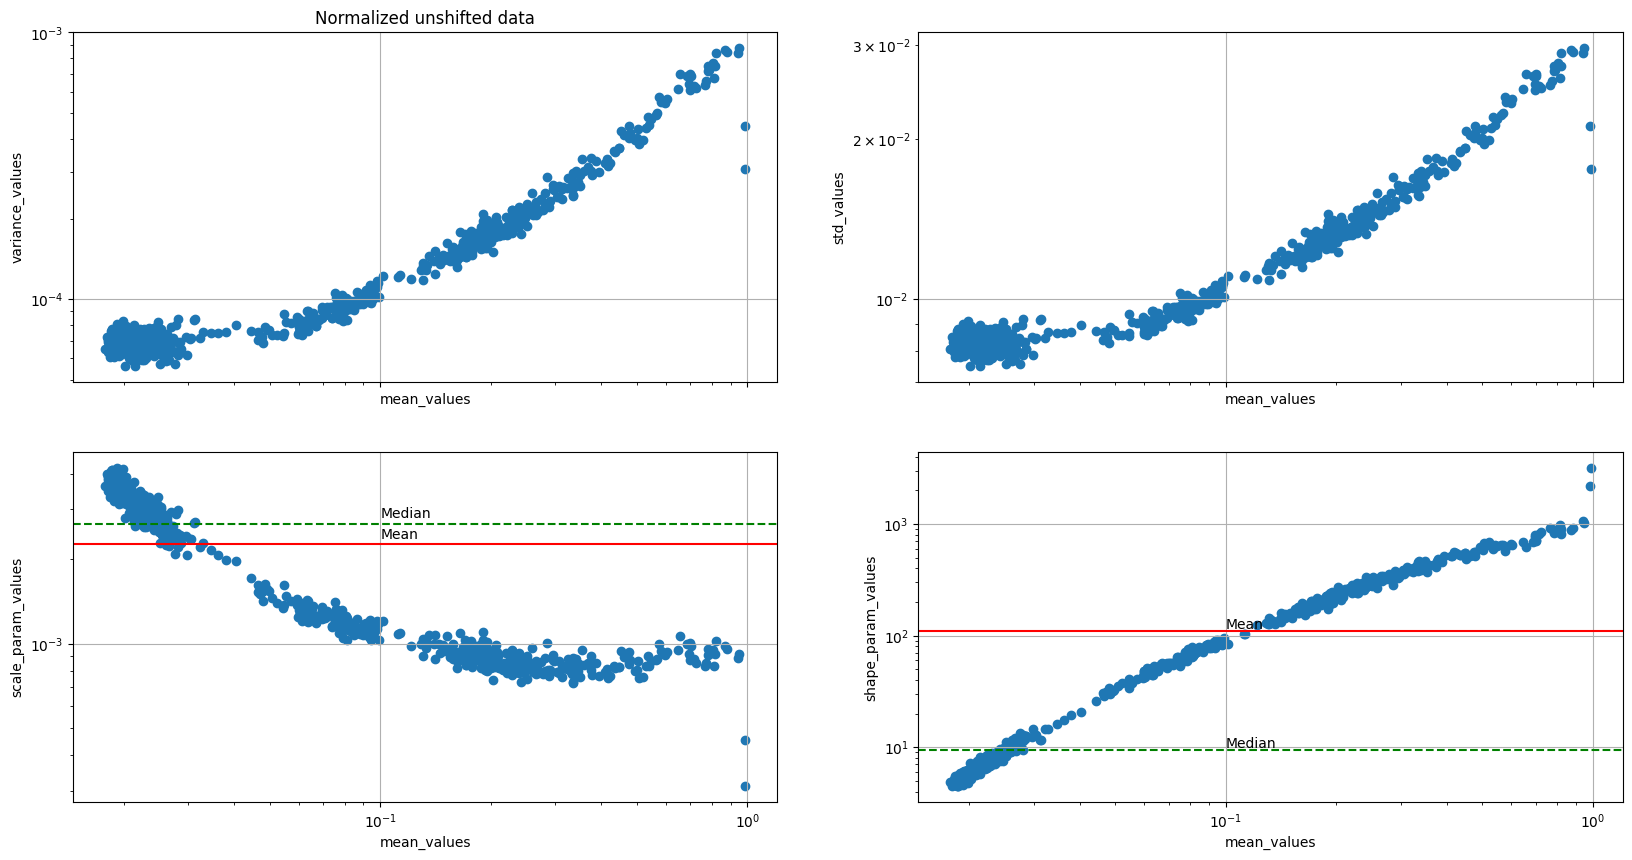

In [4]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_values, y=variance_values)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].set_title('Normalized unshifted data')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='major', axis='both')

axes[0,1].scatter(x=mean_values, y=std_values)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('std_values')
# axes[0,1].set_title('Normalized data')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='major', axis='both')

axes[1,0].scatter(x=mean_values, y=scale_param_values)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('scale_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,0].set_yscale('log')
axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='major', axis='both')
axes[1,0].axhline(y=scale_param_values.mean(), color='r', linestyle='-')
axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values.mean()))
axes[1,0].axhline(y=scale_param_values.median(), color='g', linestyle='--')
axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values.median()))

axes[1,1].scatter(x=mean_values, y=shape_param_values)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('shape_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='major', axis='both')
axes[1,1].axhline(y=shape_param_values.mean(), color='r', linestyle='-')
axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values.mean()))
axes[1,1].axhline(y=shape_param_values.median(), color='g', linestyle='--')
axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values.median()))

plt.show()

In [5]:
dataset2 = preprocess_dataset(
    xr.load_dataarray(datadir / f"SiC_100x10.nc")
) - 0.1
dataset2

Dropped 19 spectra


<xarray.DataArray (wave_number: 1015, spectra: 981)>
array([[0.06254566, 0.08294691, 0.05638902, ..., 0.06738384, 0.0543037 ,
        0.0697908 ],
       [0.10074277, 0.08296624, 0.07906306, ..., 0.08455541, 0.06925775,
        0.09019273],
       [0.06735003, 0.0935588 , 0.07774933, ..., 0.09560624, 0.0892    ,
        0.07109781],
       ...,
       [0.01958555, 0.02975454, 0.03703815, ..., 0.07193183, 0.04866816,
        0.02709968],
       [0.04343844, 0.04791769, 0.03038707, ..., 0.06735465, 0.05490049,
        0.06212035],
       [0.03449549, 0.0759778 , 0.02705697, ..., 0.05816993, 0.04867932,
        0.04461304]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 99 99 99 99 99 99 99 99
  * X_1          (spectra) int64 0 1 2 3 4 5 6 7 8 9 0 ... 9 0 1 2 3 4 5 6 7 8 9

In [6]:
ds_1 = full_ds.reset_index("spectra", drop=True)
ds_2 = dataset2.reset_index("spectra", drop=True)
combined_ds = xr.concat([ds_1, ds_2], dim="spectra", join="outer")
combined_ds = combined_ds.fillna(-2)
combined_ds

<xarray.DataArray (wave_number: 2030, spectra: 1551)>
array([[-2.        , -2.        , -2.        , ...,  0.06738384,
         0.0543037 ,  0.0697908 ],
       [ 0.06321972,  0.06322556,  0.07688599, ..., -2.        ,
        -2.        , -2.        ],
       [-2.        , -2.        , -2.        , ...,  0.08455541,
         0.06925775,  0.09019273],
       ...,
       [ 0.01359051,  0.02230961,  0.0182329 , ..., -2.        ,
        -2.        , -2.        ],
       [-2.        , -2.        , -2.        , ...,  0.05816993,
         0.04867932,  0.04461304],
       [ 0.01026167,  0.0111595 ,  0.02050487, ..., -2.        ,
        -2.        , -2.        ]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.278e+03 ... 2.82e+03 2.82e+03
Dimensions without coordinates: spectra

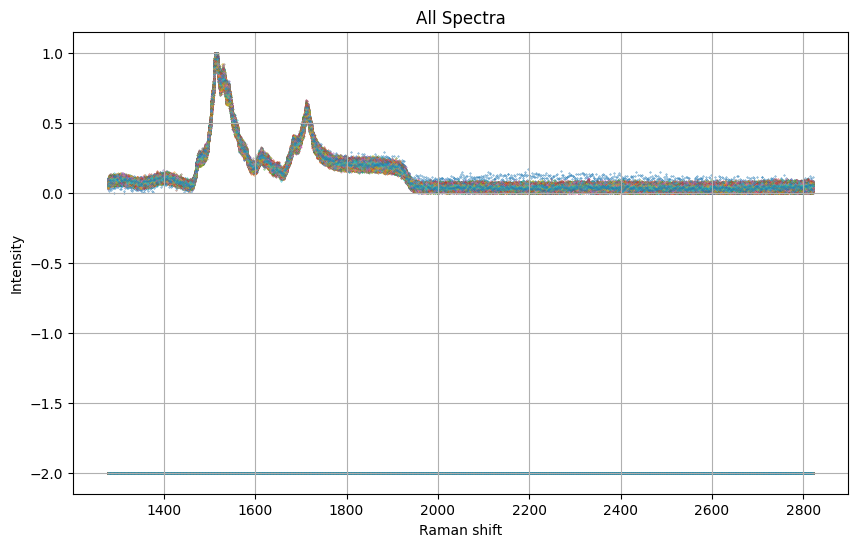

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(combined_ds.spectra.size):
    ax.scatter(combined_ds["wave_number"], combined_ds.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra')

ax.grid(visible=True, which='both', axis='both')

plt.show()

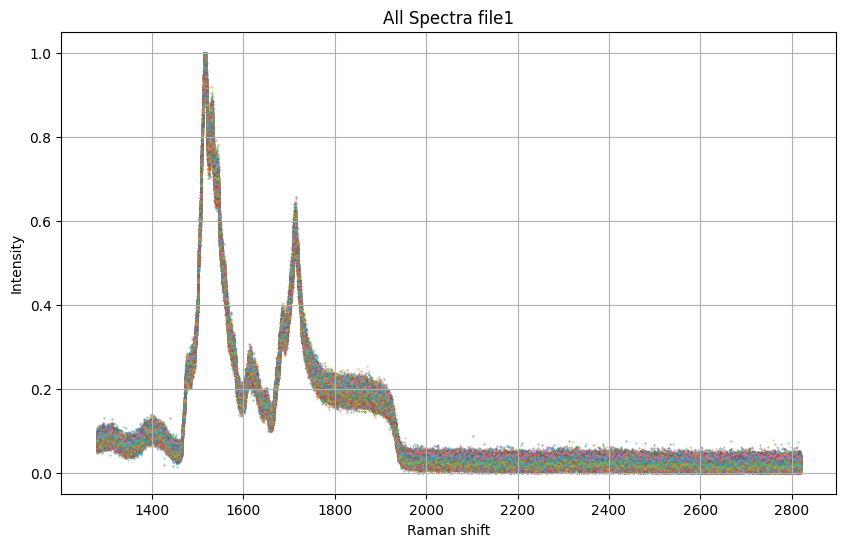

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(ds_1.spectra.size):
    ax.scatter(ds_1["wave_number"], ds_1.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra file1')

ax.grid(visible=True, which='both', axis='both')

plt.show()

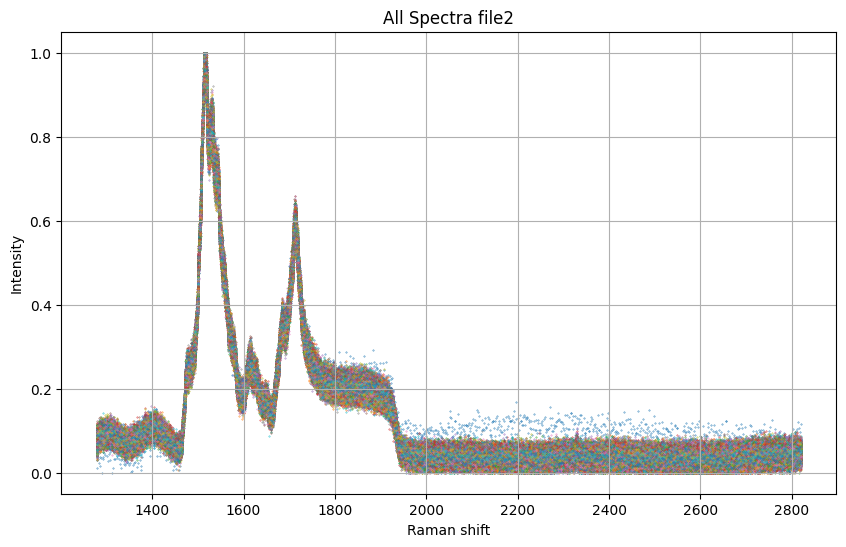

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(ds_2.spectra.size):
    ax.scatter(ds_2["wave_number"], ds_2.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra file2')

ax.grid(visible=True, which='both', axis='both')

plt.show()

In [10]:
mean_values1 = ds_1.mean(
    dim=['spectra']
)

variance_values1 = ds_1.var(
    dim=['spectra']
)

std_values1 = ds_1.std(
    dim=['spectra']
)

scale_param_values1 = variance_values1 / mean_values1

shape_param_values1 = mean_values1**2 / std_values1**2

In [11]:
mean_values2 = ds_2.mean(
    dim=['spectra']
)

variance_values2 = ds_2.var(
    dim=['spectra']
)

std_values2 = ds_2.std(
    dim=['spectra']
)

scale_param_values2 = variance_values2 / mean_values2

shape_param_values2 = mean_values2**2 / std_values2**2

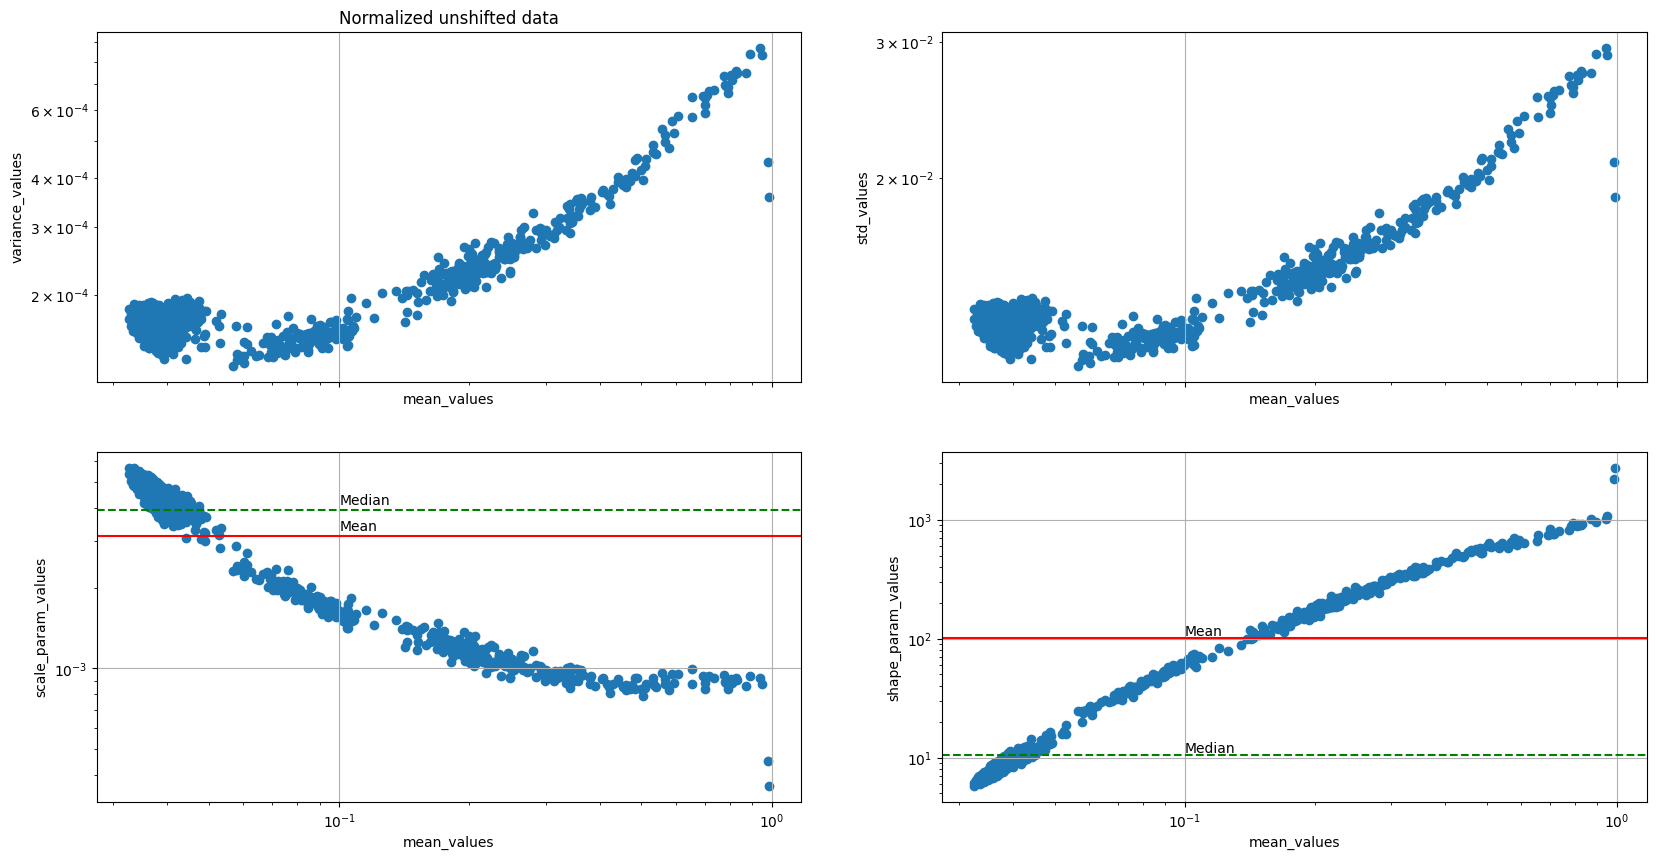

In [12]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_values2, y=variance_values2)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].set_title('Normalized unshifted data')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='major', axis='both')

axes[0,1].scatter(x=mean_values2, y=std_values2)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('std_values')
# axes[0,1].set_title('Normalized data')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='major', axis='both')

axes[1,0].scatter(x=mean_values2, y=scale_param_values2)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('scale_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,0].set_yscale('log')
axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='major', axis='both')
axes[1,0].axhline(y=scale_param_values2.mean(), color='r', linestyle='-')
axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values2.mean()))
axes[1,0].axhline(y=scale_param_values2.median(), color='g', linestyle='--')
axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values2.median()))

axes[1,1].scatter(x=mean_values2, y=shape_param_values2)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('shape_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='major', axis='both')
axes[1,1].axhline(y=shape_param_values2.mean(), color='r', linestyle='-')
axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values2.mean()))
axes[1,1].axhline(y=shape_param_values2.median(), color='g', linestyle='--')
axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values2.median()))

plt.show()

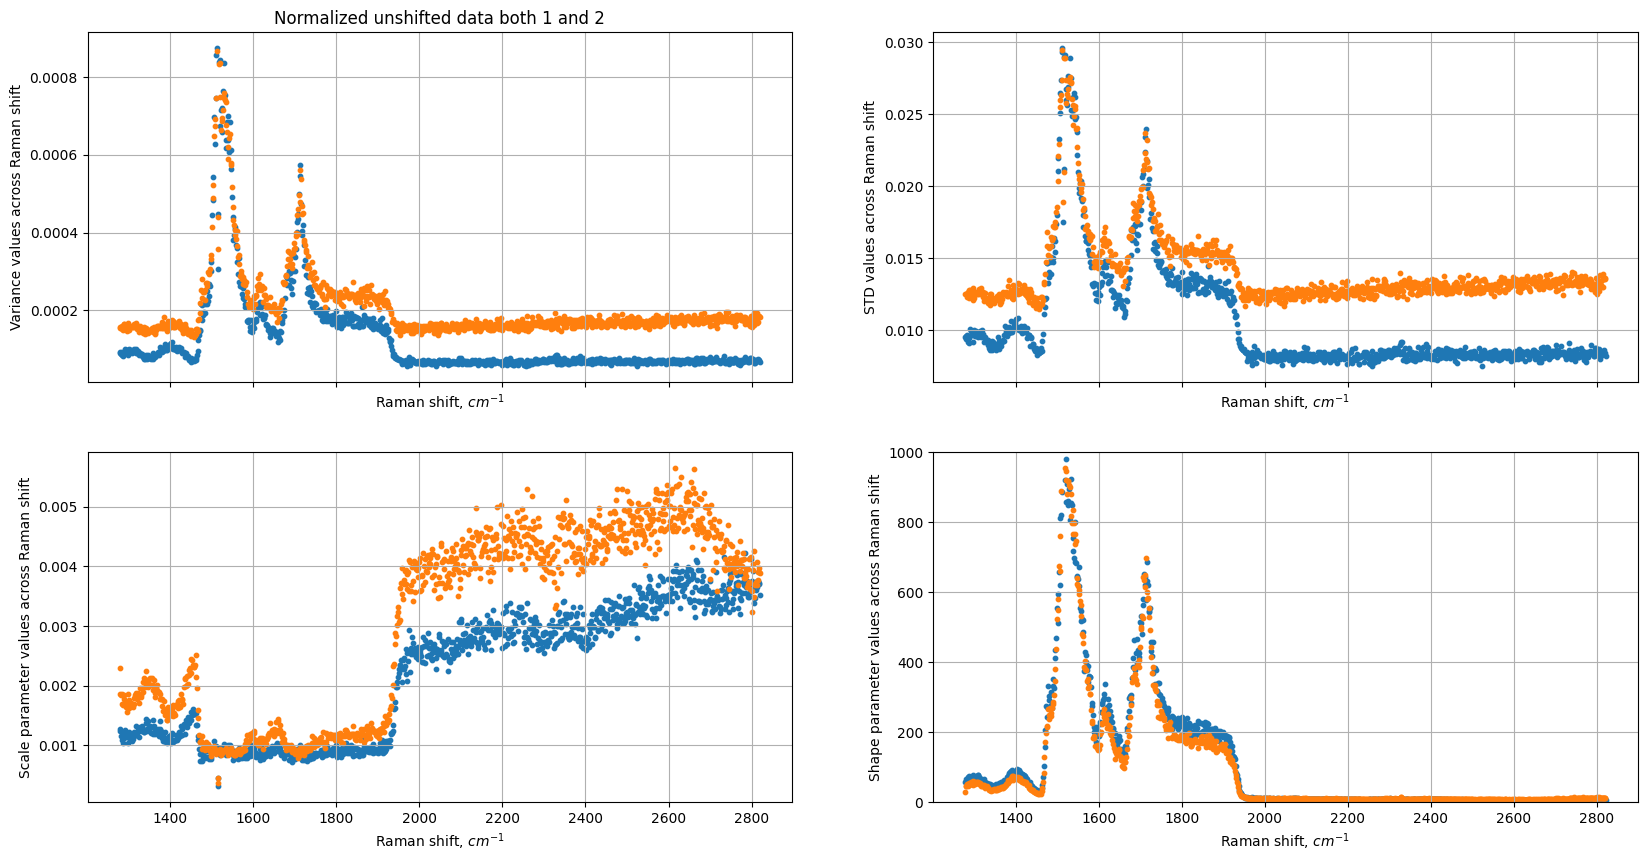

In [13]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

s=10

axes[0,0].scatter(x=ds_1['wave_number'], y=variance_values, s=s)
axes[0,0].scatter(x=ds_2['wave_number'], y=variance_values2, s=s)
axes[0,0].set_xlabel('Raman shift, $cm^{-1}$')
axes[0,0].set_ylabel('Variance values across Raman shift')
axes[0,0].set_title('Normalized unshifted data both 1 and 2')
# axes[0,0].set_yscale('log')
# axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].scatter(x=ds_1['wave_number'], y=std_values, s=s)
axes[0,1].scatter(x=ds_2['wave_number'], y=std_values2, s=s)
axes[0,1].set_xlabel('Raman shift, $cm^{-1}$')
axes[0,1].set_ylabel('STD values across Raman shift')
# axes[0,1].set_title('Normalized data')
# axes[0,1].set_yscale('log')
# axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='both', axis='both')

axes[1,0].scatter(x=ds_1['wave_number'], y=scale_param_values, s=s)
axes[1,0].scatter(x=ds_2['wave_number'], y=scale_param_values2, s=s)
axes[1,0].set_xlabel('Raman shift, $cm^{-1}$')
axes[1,0].set_ylabel('Scale parameter values across Raman shift')
# axes[0,1].set_title('Normalized data')
# axes[1,0].set_yscale('log')
# axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='both', axis='both')
# axes[1,0].axhline(y=scale_param_values2.mean(), color='r', linestyle='-')
# axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values2.mean()))
# axes[1,0].axhline(y=scale_param_values2.median(), color='g', linestyle='--')
# axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values2.median()))

axes[1,1].scatter(x=ds_1['wave_number'], y=shape_param_values, s=s)
axes[1,1].scatter(x=ds_2['wave_number'], y=shape_param_values2, s=s)
axes[1,1].set_xlabel('Raman shift, $cm^{-1}$')
axes[1,1].set_ylabel('Shape parameter values across Raman shift')
# axes[0,1].set_title('Normalized data')
# axes[1,1].set_yscale('log')
# axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
axes[1,1].set_ylim([0,1000])
axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].axhline(y=shape_param_values2.mean(), color='r', linestyle='-')
# axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values2.mean()))
# axes[1,1].axhline(y=shape_param_values2.median(), color='g', linestyle='--')
# axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values2.median()))

plt.show()
fig.savefig("temp/buffer/statistics_raman_shift.svg", transparent=True)

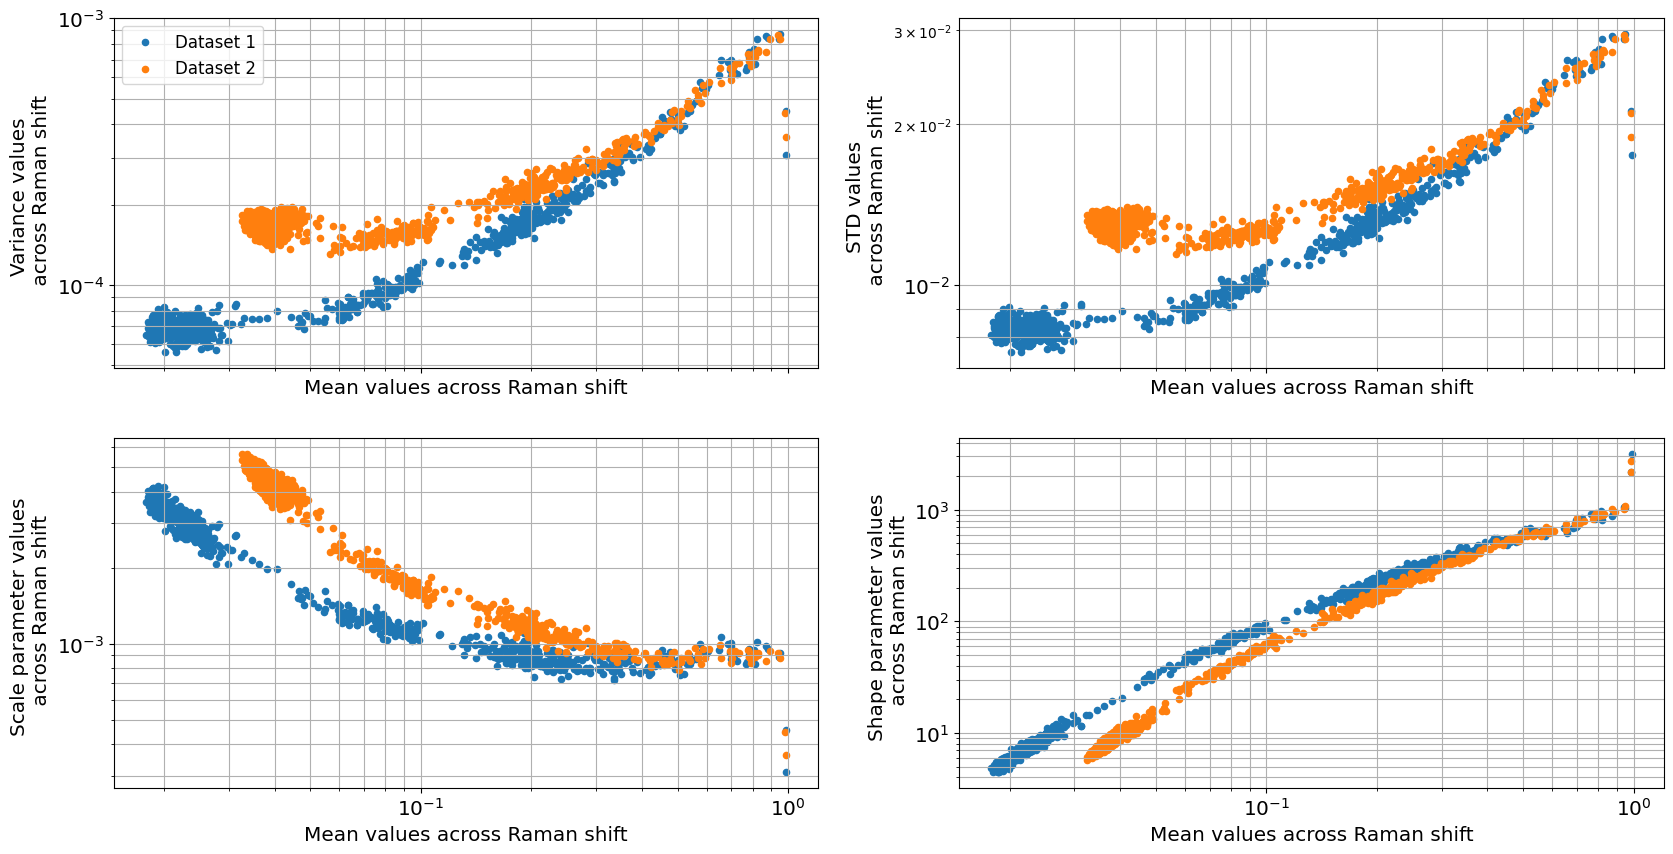

In [17]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)
s=20


axes[0,0].scatter(x=mean_values, y=variance_values, s=s)
axes[0,0].scatter(x=mean_values2, y=variance_values2, s=s)
axes[0,0].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[0,0].set_ylabel('Variance values \n across Raman shift', fontsize='x-large')
# axes[0,0].set_title('Normalized unshifted data both 1 and 2')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='both', axis='both')
axes[0,0].tick_params(axis='both', which='major', labelsize='x-large')
axes[0,0].legend(["Dataset 1", "Dataset 2"], frameon=True, fontsize='large')

axes[0,1].scatter(x=mean_values, y=std_values, s=s)
axes[0,1].scatter(x=mean_values2, y=std_values2, s=s)
axes[0,1].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[0,1].set_ylabel('STD values \n across Raman shift', fontsize='x-large')
# axes[0,1].set_title('Normalized data')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='both', axis='both')
axes[0,1].tick_params(axis='both', which='major', labelsize='x-large')

axes[1,0].scatter(x=mean_values, y=scale_param_values, s=s)
axes[1,0].scatter(x=mean_values2, y=scale_param_values2, s=s)
axes[1,0].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[1,0].set_ylabel('Scale parameter values \n across Raman shift', fontsize='x-large')
# axes[0,1].set_title('Normalized data')
axes[1,0].set_yscale('log')
axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='both', axis='both')
# axes[1,0].axhline(y=scale_param_values2.mean(), color='r', linestyle='-')
# axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values2.mean()))
# axes[1,0].axhline(y=scale_param_values2.median(), color='g', linestyle='--')
# axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values2.median()))
axes[1,0].tick_params(axis='both', which='major', labelsize='x-large')

axes[1,1].scatter(x=mean_values, y=shape_param_values, s=s)
axes[1,1].scatter(x=mean_values2, y=shape_param_values2, s=s)
axes[1,1].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[1,1].set_ylabel('Shape parameter values \n across Raman shift', fontsize='x-large')
# axes[0,1].set_title('Normalized data')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].axhline(y=shape_param_values2.mean(), color='r', linestyle='-')
# axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values2.mean()))
# axes[1,1].axhline(y=shape_param_values2.median(), color='g', linestyle='--')
# axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values2.median()))
axes[1,1].tick_params(axis='both', which='major', labelsize='x-large')

plt.show()
fig.savefig("temp/buffer/statistics_log.svg", transparent=True)

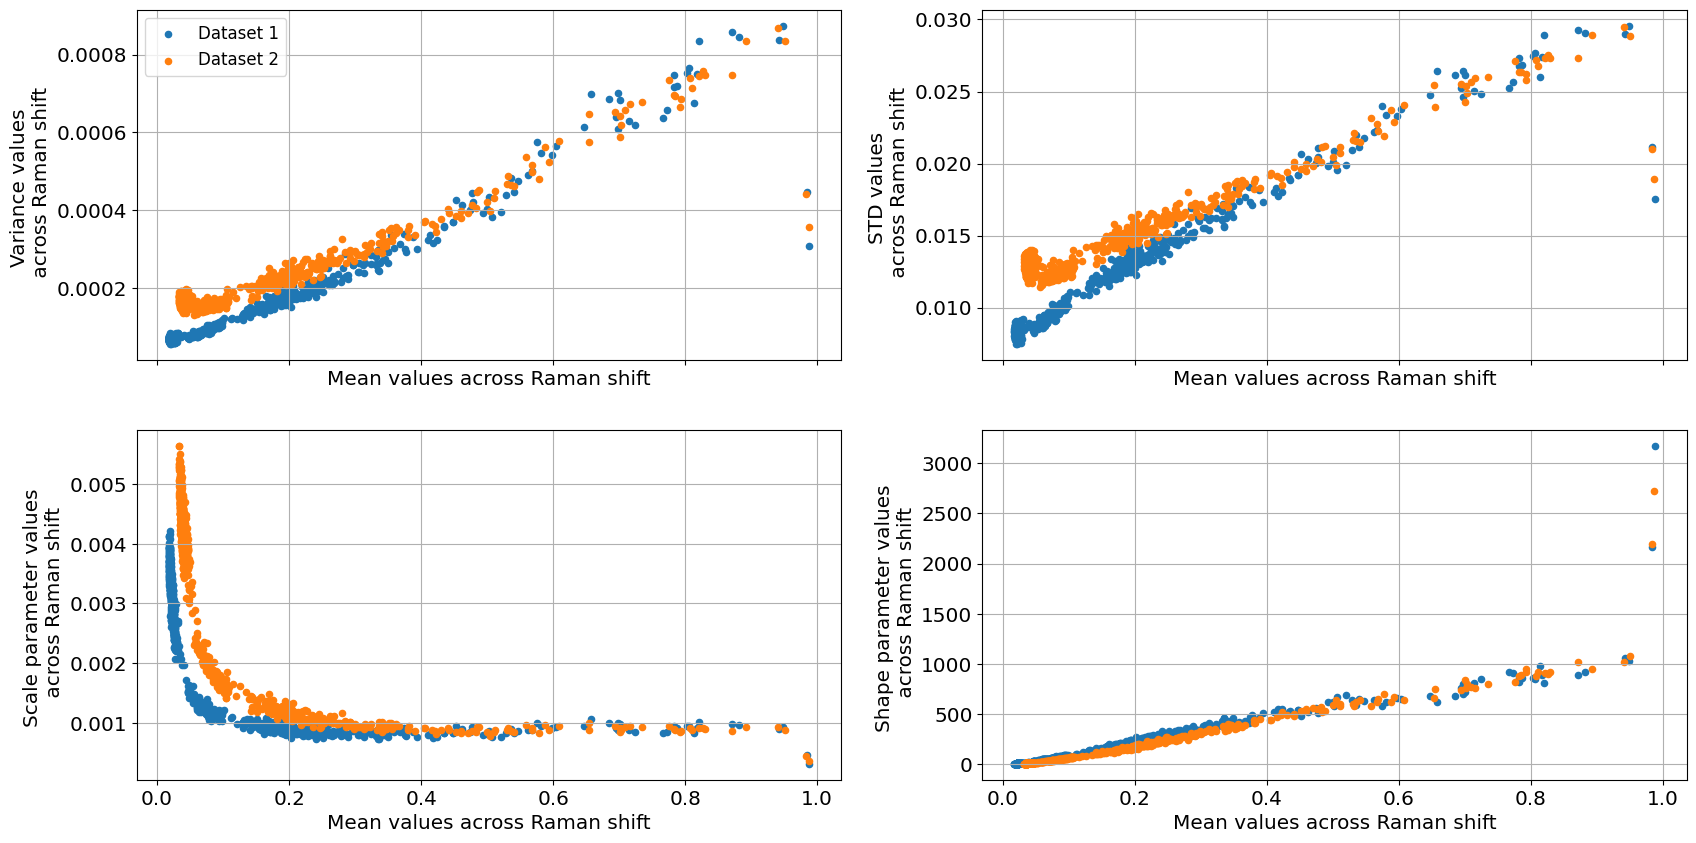

In [18]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)
s=20


axes[0,0].scatter(x=mean_values, y=variance_values, s=s)
axes[0,0].scatter(x=mean_values2, y=variance_values2, s=s)
axes[0,0].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[0,0].set_ylabel('Variance values \n across Raman shift', fontsize='x-large')
# axes[0,0].set_title('Normalized unshifted data both 1 and 2')
# axes[0,0].set_yscale('log')
# axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='both', axis='both')
axes[0,0].tick_params(axis='both', which='major', labelsize='x-large')
axes[0,0].legend(["Dataset 1", "Dataset 2"], frameon=True, fontsize='large')

axes[0,1].scatter(x=mean_values, y=std_values, s=s)
axes[0,1].scatter(x=mean_values2, y=std_values2, s=s)
axes[0,1].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[0,1].set_ylabel('STD values \n across Raman shift', fontsize='x-large')
# axes[0,1].set_title('Normalized data')
# axes[0,1].set_yscale('log')
# axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='both', axis='both')
axes[0,1].tick_params(axis='both', which='major', labelsize='x-large')

axes[1,0].scatter(x=mean_values, y=scale_param_values, s=s)
axes[1,0].scatter(x=mean_values2, y=scale_param_values2, s=s)
axes[1,0].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[1,0].set_ylabel('Scale parameter values \n across Raman shift', fontsize='x-large')
# axes[0,1].set_title('Normalized data')
# axes[1,0].set_yscale('log')
# axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='both', axis='both')
# axes[1,0].axhline(y=scale_param_values2.mean(), color='r', linestyle='-')
# axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values2.mean()))
# axes[1,0].axhline(y=scale_param_values2.median(), color='g', linestyle='--')
# axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values2.median()))
axes[1,0].tick_params(axis='both', which='major', labelsize='x-large')

axes[1,1].scatter(x=mean_values, y=shape_param_values, s=s)
axes[1,1].scatter(x=mean_values2, y=shape_param_values2, s=s)
axes[1,1].set_xlabel('Mean values across Raman shift', fontsize='x-large')
axes[1,1].set_ylabel('Shape parameter values \n across Raman shift', fontsize='x-large')
# axes[0,1].set_title('Normalized data')
# axes[1,1].set_yscale('log')
# axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].axhline(y=shape_param_values2.mean(), color='r', linestyle='-')
# axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values2.mean()))
# axes[1,1].axhline(y=shape_param_values2.median(), color='g', linestyle='--')
# axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values2.median()))
axes[1,1].tick_params(axis='both', which='major', labelsize='x-large')

plt.show()
fig.savefig("temp/buffer/statistics_normal.svg", transparent=True)

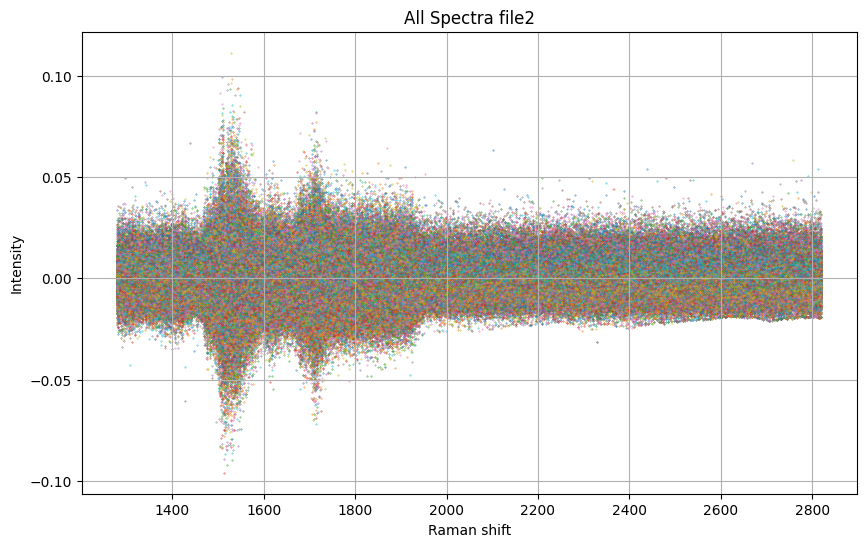

In [12]:
meancheck = ds_1 - ds_1.mean(dim=['spectra'])
fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(meancheck.spectra.size):
    ax.scatter(meancheck["wave_number"], meancheck.isel(spectra=i), alpha=1, s=0.1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra file2')

ax.grid(visible=True, which='both', axis='both')

plt.show()

In [13]:
def my_statistics(
    dataset,
    dim: str = 'spectra'
    ):
    exp_val = dataset.mean(dim=[dim])
    variance = dataset.var(dim=[dim])
    std = dataset.std(dim=[dim])
    z1 = (dataset - exp_val)/std
    skewness = (z1**3).mean(dim=[dim])
    kurtosis = (z1**4).mean(dim=[dim])
    
    return exp_val, variance, std, skewness, kurtosis

In [14]:
mean1 , var1, std1, skew1, kurt1 = my_statistics(ds_1)
mean2 , var2, std2, skew2, kurt2 = my_statistics(ds_2)
print(skew1)
print(kurt1)

<xarray.DataArray (wave_number: 1015)>
array([0.34454645, 0.1155957 , 0.24360064, ..., 0.53538707, 0.60161758,
       0.47515322])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
<xarray.DataArray (wave_number: 1015)>
array([3.28624519, 2.95513412, 3.27380021, ..., 3.61703528, 3.49706157,
       3.206646  ])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03


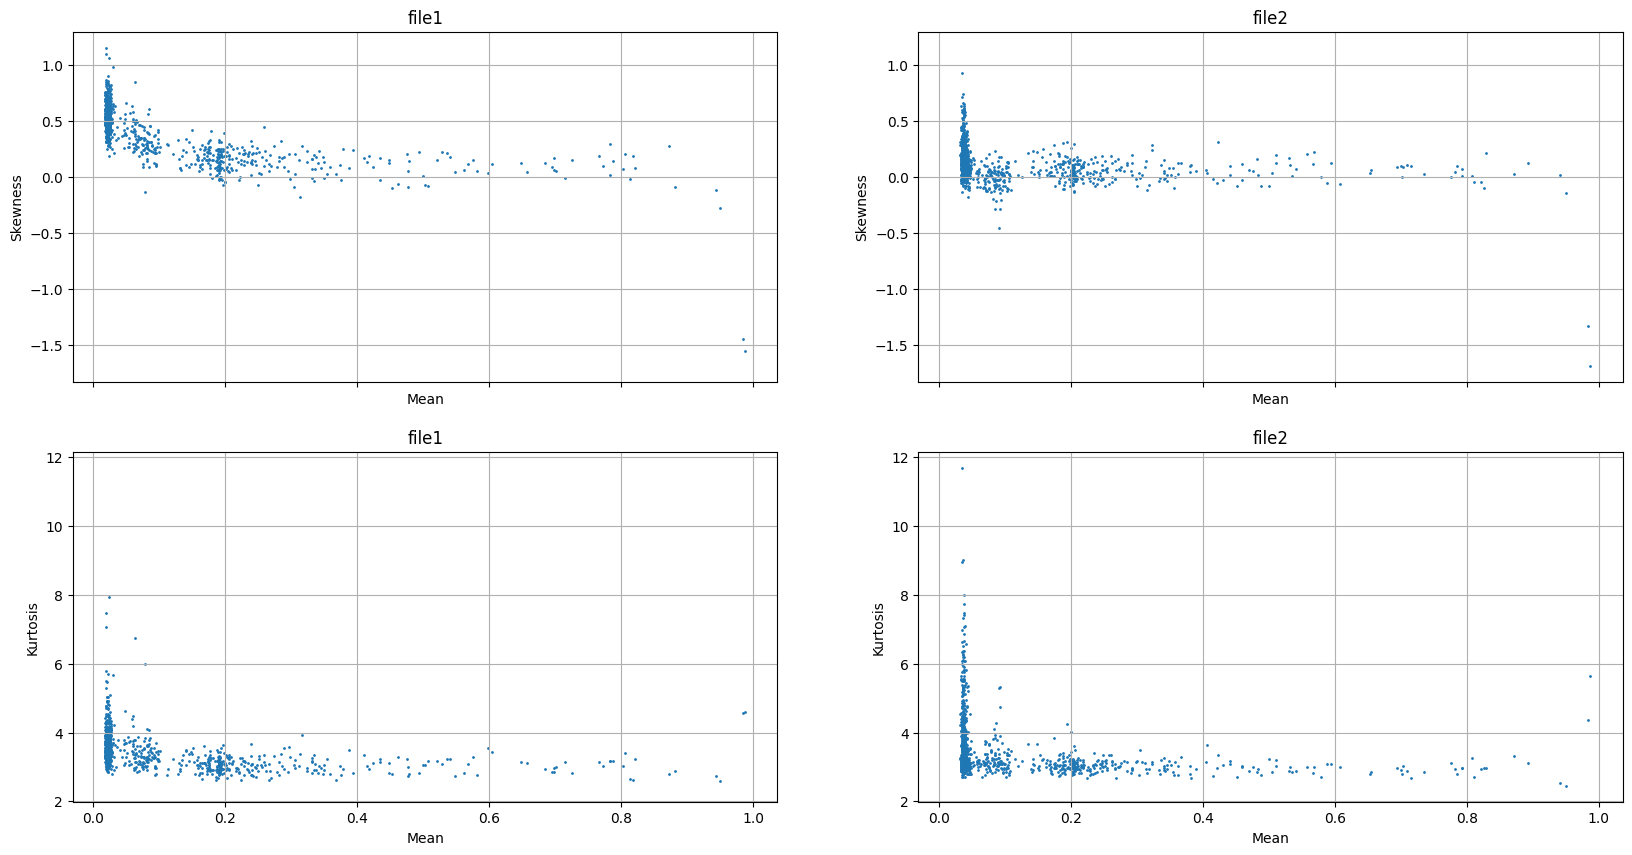

In [15]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean1, y=skew1, alpha=1, s=1)
axes[0,0].set_xlabel('Mean')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('file1')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].scatter(x=mean2, y=skew2, alpha=1, s=1)
axes[0,1].set_xlabel('Mean')
axes[0,1].set_ylabel('Skewness')
axes[0,1].set_title('file2')
axes[0,1].grid(visible=True, which='both', axis='both')
axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=mean1, y=kurt1, alpha=1, s=1)
axes[1,0].set_xlabel('Mean')
axes[1,0].set_ylabel('Kurtosis')
axes[1,0].set_title('file1')
axes[1,0].grid(visible=True, which='both', axis='both')

axes[1,1].scatter(x=mean2, y=kurt2, alpha=1, s=1)
axes[1,1].set_xlabel('Mean')
axes[1,1].set_ylabel('Kurtosis')
axes[1,1].set_title('file2')
axes[1,1].grid(visible=True, which='both', axis='both')
axes[1,1].sharey(axes[1,0])

plt.show()

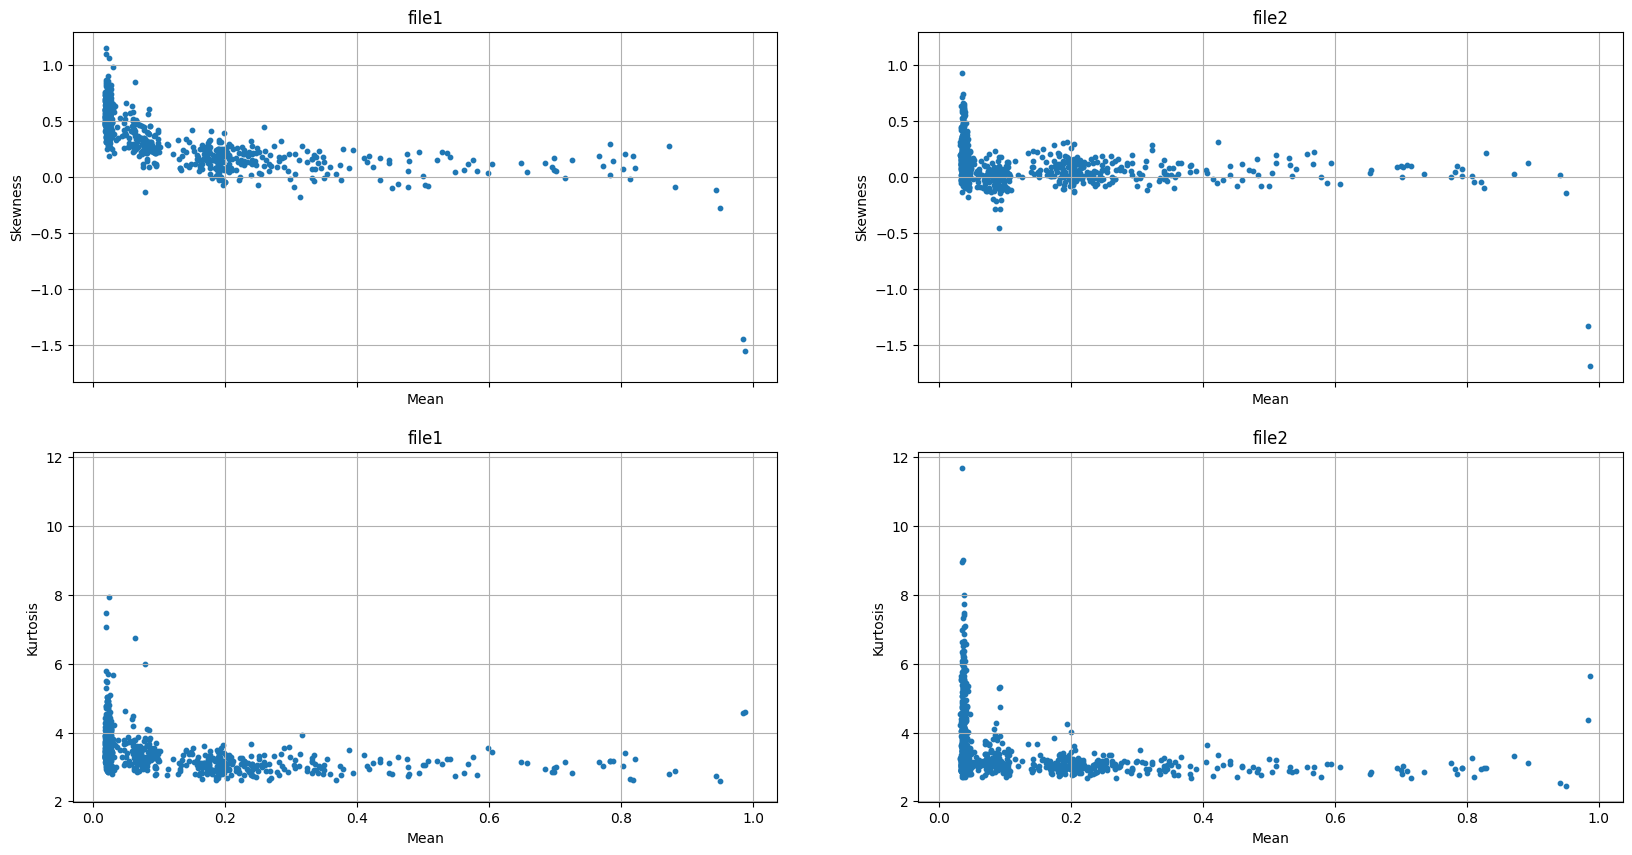

In [16]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean1, y=skew1, alpha=1, s=10)
axes[0,0].set_xlabel('Mean')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('file1')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].scatter(x=mean2, y=skew2, alpha=1, s=10)
axes[0,1].set_xlabel('Mean')
axes[0,1].set_ylabel('Skewness')
axes[0,1].set_title('file2')
axes[0,1].grid(visible=True, which='both', axis='both')
axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=mean1, y=kurt1, alpha=1, s=10)
axes[1,0].set_xlabel('Mean')
axes[1,0].set_ylabel('Kurtosis')
axes[1,0].set_title('file1')
axes[1,0].grid(visible=True, which='both', axis='both')

axes[1,1].scatter(x=mean2, y=kurt2, alpha=1, s=10)
axes[1,1].set_xlabel('Mean')
axes[1,1].set_ylabel('Kurtosis')
axes[1,1].set_title('file2')
axes[1,1].grid(visible=True, which='both', axis='both')
axes[1,1].sharey(axes[1,0])

plt.show()

In [18]:
ds_raw = preprocess_dataset_raw(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc"), raw = True
)
ds_raw

<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[74.983772, 73.513504, 67.632423, ..., 86.745934, 85.275658,
        72.043228],
       [91.177582, 73.530304, 70.589096, ..., 77.942123, 83.824547,
        66.177277],
       [85.314659, 73.547119, 63.250523, ..., 85.314659, 85.314659,
        63.250523],
       ...,
       [29.386446, 27.549793, 18.366529, ..., 36.733059, 25.71314 ,
        20.203182],
       [20.207445, 33.06673 , 20.207445, ..., 34.90377 , 29.392649,
        18.370405],
       [16.533365, 22.044485, 22.044485, ..., 27.555607, 23.881527,
        34.90377 ]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4
Attributes:
    system_type:  SiC

In [19]:
mean_raw , var_raw, std_raw, skew_raw, kurt_raw = my_statistics(ds_raw)

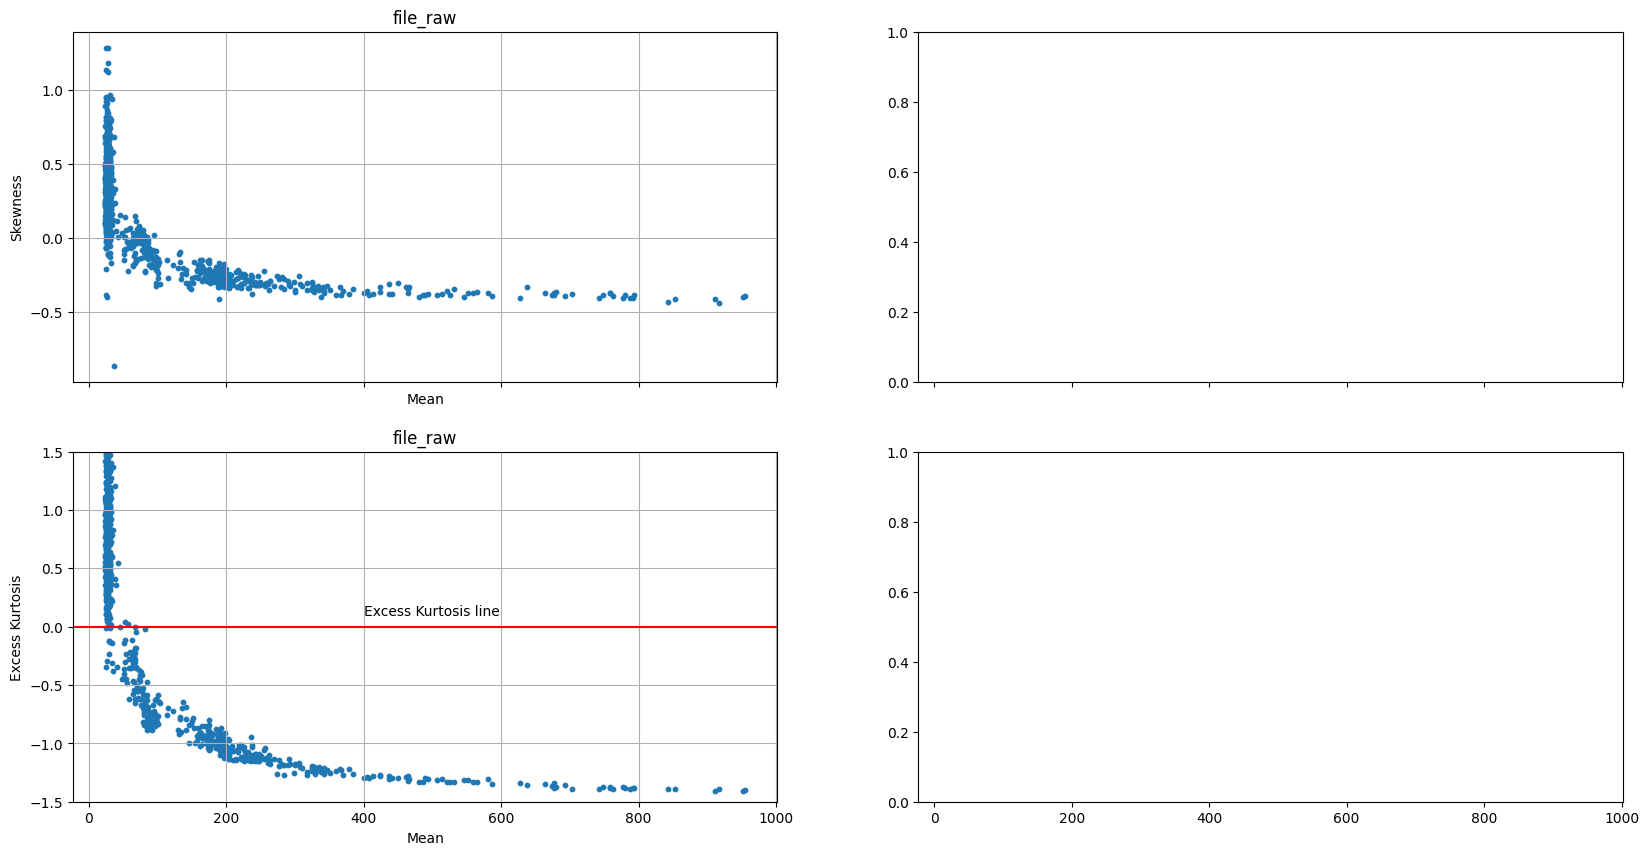

In [33]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_raw, y=skew_raw, alpha=1, s=10)
axes[0,0].set_xlabel('Mean')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('file_raw')
axes[0,0].grid(visible=True, which='both', axis='both')

# axes[0,1].scatter(x=mean2, y=skew2, alpha=1, s=10)
# axes[0,1].set_xlabel('Mean')
# axes[0,1].set_ylabel('Skewness')
# axes[0,1].set_title('file2')
# axes[0,1].grid(visible=True, which='both', axis='both')
# axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=mean_raw, y=kurt_raw-3, alpha=1, s=10)
axes[1,0].set_xlabel('Mean')
axes[1,0].set_ylabel('Excess Kurtosis')
axes[1,0].set_title('file_raw')
axes[1,0].grid(visible=True, which='both', axis='both')
axes[1,0].axhline(y=0, color='r', linestyle='-')
axes[1,0].annotate('Excess Kurtosis line', (400,0.1))
axes[1,0].set_ylim([-1.5,1.5])
# axes[1,0].set_xlim([400,1000])

# axes[1,1].scatter(x=mean2, y=kurt2, alpha=1, s=10)
# axes[1,1].set_xlabel('Mean')
# axes[1,1].set_ylabel('Kurtosis')
# axes[1,1].set_title('file2')
# axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].sharey(axes[1,0])

plt.show()

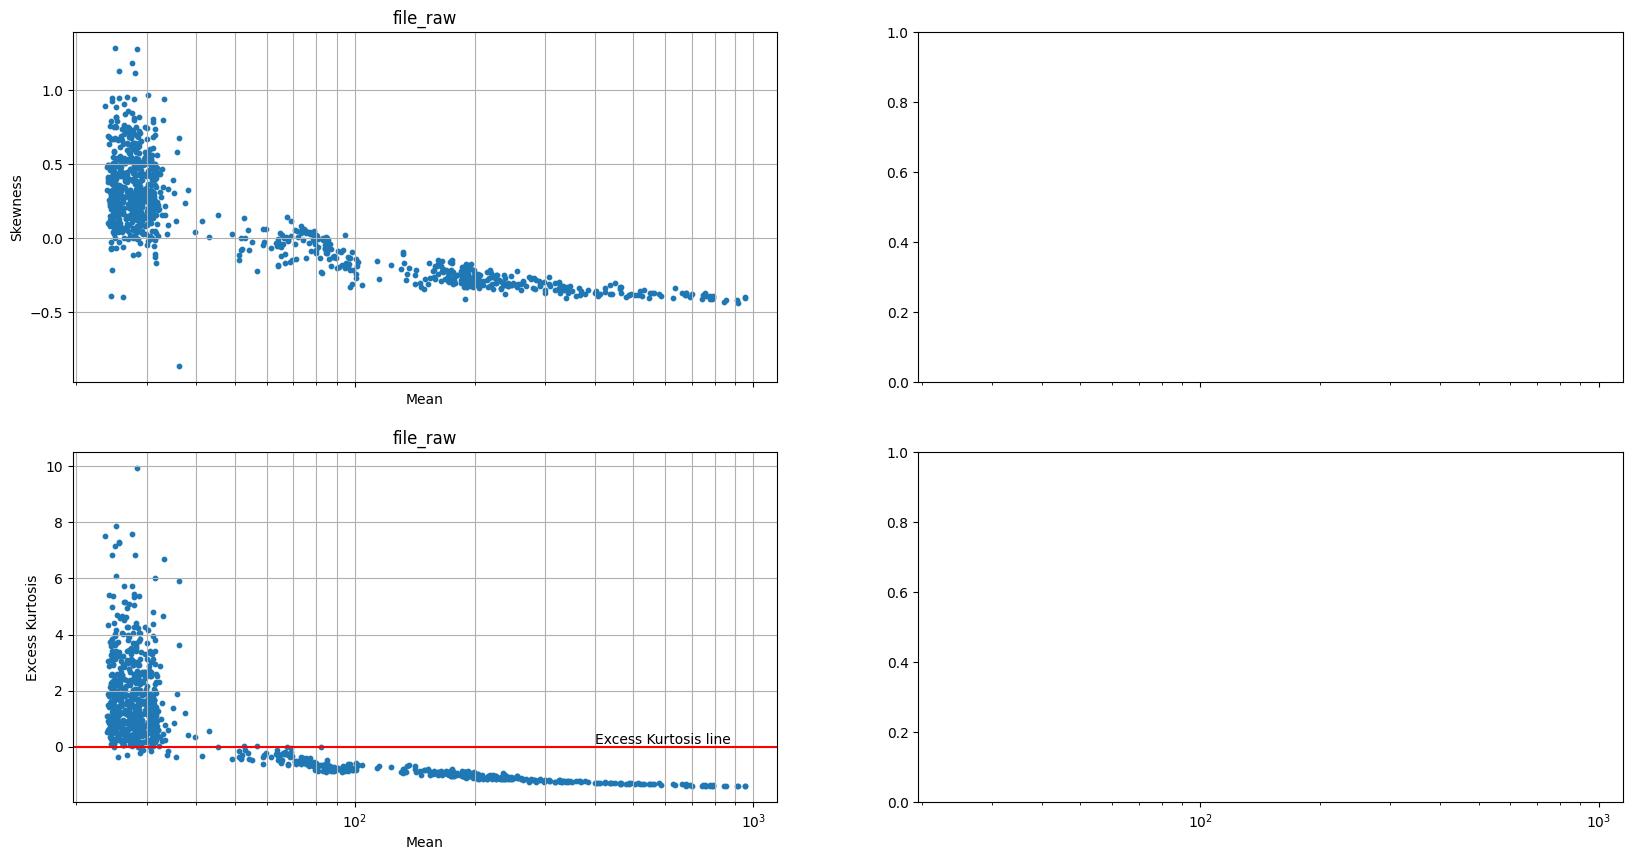

In [36]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_raw, y=skew_raw, alpha=1, s=10)
axes[0,0].set_xlabel('Mean')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('file_raw')
axes[0,0].grid(visible=True, which='both', axis='both')
axes[0,0].set_xscale('log')

# axes[0,1].scatter(x=mean2, y=skew2, alpha=1, s=10)
# axes[0,1].set_xlabel('Mean')
# axes[0,1].set_ylabel('Skewness')
# axes[0,1].set_title('file2')
# axes[0,1].grid(visible=True, which='both', axis='both')
# axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=mean_raw, y=kurt_raw-3, alpha=1, s=10)
axes[1,0].set_xlabel('Mean')
axes[1,0].set_ylabel('Excess Kurtosis')
axes[1,0].set_title('file_raw')
axes[1,0].grid(visible=True, which='both', axis='both')
axes[1,0].axhline(y=0, color='r', linestyle='-')
axes[1,0].annotate('Excess Kurtosis line', (400,0.1))
# axes[1,0].set_ylim([-1.5,1.5])
axes[1,0].set_xscale('log')
# axes[1,0].set_xlim([400,1000])

# axes[1,1].scatter(x=mean2, y=kurt2, alpha=1, s=10)
# axes[1,1].set_xlabel('Mean')
# axes[1,1].set_ylabel('Kurtosis')
# axes[1,1].set_title('file2')
# axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].sharey(axes[1,0])

plt.show()

In [55]:
ds_raw

<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[74.983772, 73.513504, 67.632423, ..., 86.745934, 85.275658,
        72.043228],
       [91.177582, 73.530304, 70.589096, ..., 77.942123, 83.824547,
        66.177277],
       [85.314659, 73.547119, 63.250523, ..., 85.314659, 85.314659,
        63.250523],
       ...,
       [29.386446, 27.549793, 18.366529, ..., 36.733059, 25.71314 ,
        20.203182],
       [20.207445, 33.06673 , 20.207445, ..., 34.90377 , 29.392649,
        18.370405],
       [16.533365, 22.044485, 22.044485, ..., 27.555607, 23.881527,
        34.90377 ]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4
Attributes:
    system_type:  SiC

In [49]:
for i in range(ds_raw.wave_number.size):
    print(i, ds_raw.wave_number[i].values)

0 1278.296875
1 1279.998047
2 1281.697266
3 1283.396484
4 1285.095703
5 1286.794922
6 1288.494141
7 1290.191406
8 1291.888672
9 1293.585938
10 1295.283203
11 1296.980469
12 1298.675781
13 1300.371094
14 1302.066406
15 1303.761719
16 1305.457031
17 1307.150391
18 1308.84375
19 1310.537109
20 1312.230469
21 1313.923828
22 1315.615234
23 1317.308594
24 1319.0
25 1320.689453
26 1322.380859
27 1324.070313
28 1325.761719
29 1327.451172
30 1329.138672
31 1330.828125
32 1332.517578
33 1334.205078
34 1335.892578
35 1337.580078
36 1339.265625
37 1340.953125
38 1342.638672
39 1344.324219
40 1346.009766
41 1347.693359
42 1349.378906
43 1351.0625
44 1352.746094
45 1354.429688
46 1356.113281
47 1357.794922
48 1359.476563
49 1361.160156
50 1362.839844
51 1364.521484
52 1366.203125
53 1367.882813
54 1369.5625
55 1371.242188
56 1372.919922
57 1374.599609
58 1376.277344
59 1377.955078
60 1379.632813
61 1381.310547
62 1382.986328
63 1384.664063
64 1386.339844
65 1388.015625
66 1389.689453
67 1391.365234


In [57]:
ds_raw_1 = ds_raw.reset_index("spectra", drop=True)
ds_raw_1

<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[74.983772, 73.513504, 67.632423, ..., 86.745934, 85.275658,
        72.043228],
       [91.177582, 73.530304, 70.589096, ..., 77.942123, 83.824547,
        66.177277],
       [85.314659, 73.547119, 63.250523, ..., 85.314659, 85.314659,
        63.250523],
       ...,
       [29.386446, 27.549793, 18.366529, ..., 36.733059, 25.71314 ,
        20.203182],
       [20.207445, 33.06673 , 20.207445, ..., 34.90377 , 29.392649,
        18.370405],
       [16.533365, 22.044485, 22.044485, ..., 27.555607, 23.881527,
        34.90377 ]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Dimensions without coordinates: spectra
Attributes:
    system_type:  SiC

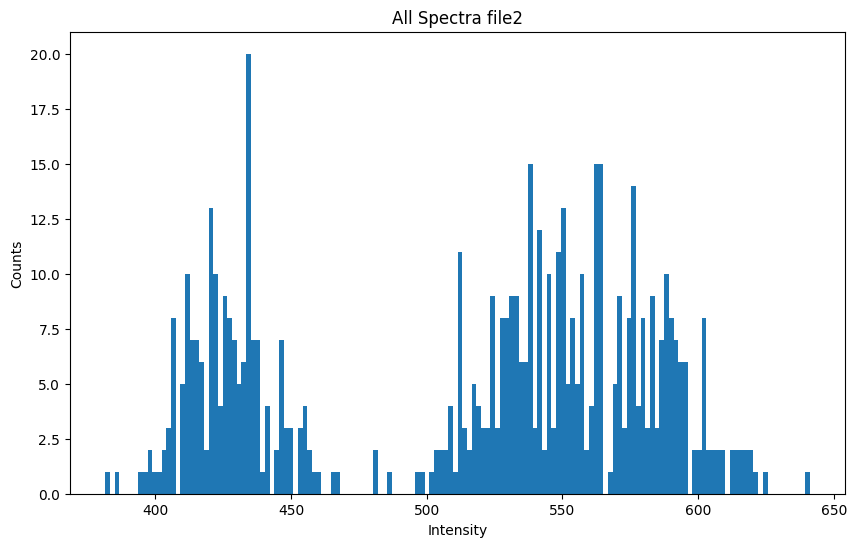

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(ds_raw.isel(wave_number=163), bins=150) #1550cm-1

# ax.hist(ds_raw.isel(wave_number=400), bins=100)
# ax.hist(ds_raw.isel(wave_number=600), bins=100)
# ax.hist(ds_raw.isel(wave_number=800), bins=100)
# ax.hist(ds_raw.isel(wave_number=1000), bins=100)
ax.set_xlabel('Intensity')
ax.set_ylabel('Counts')
ax.set_title('All Spectra file2')

plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 600))
axes = fig.subplots(475, 1, sharex=True)
for i in range(475):
    axes[i].hist( ds_raw.isel(wave_number=i), bins=150)
    axes[i].set_title(f'Point number {i}: {ds_raw.wave_number[i].values} cm-1')
    axes[i].set_xlabel('Intensity')
    axes[i].set_ylabel('Counts')
plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 600))
axes = fig.subplots(475, 1, sharex=True)
for i in range(475):
    axes[i].hist( ds_raw.isel(wave_number=i), bins=150)
    axes[i].set_title(f'Point number {i}: {ds_raw.wave_number[i].values} cm-1')
    axes[i].set_xlabel('Intensity')
    axes[i].set_ylabel('Counts')
plt.show()

In [89]:
ds_raw2 = preprocess_dataset_raw(
    xr.load_dataarray(datadir / f"SiC_100x10.nc"), raw = True
)
mean_raw2 , var_raw2, std_raw2, skew_raw2, kurt_raw2 = my_statistics(ds_raw2)

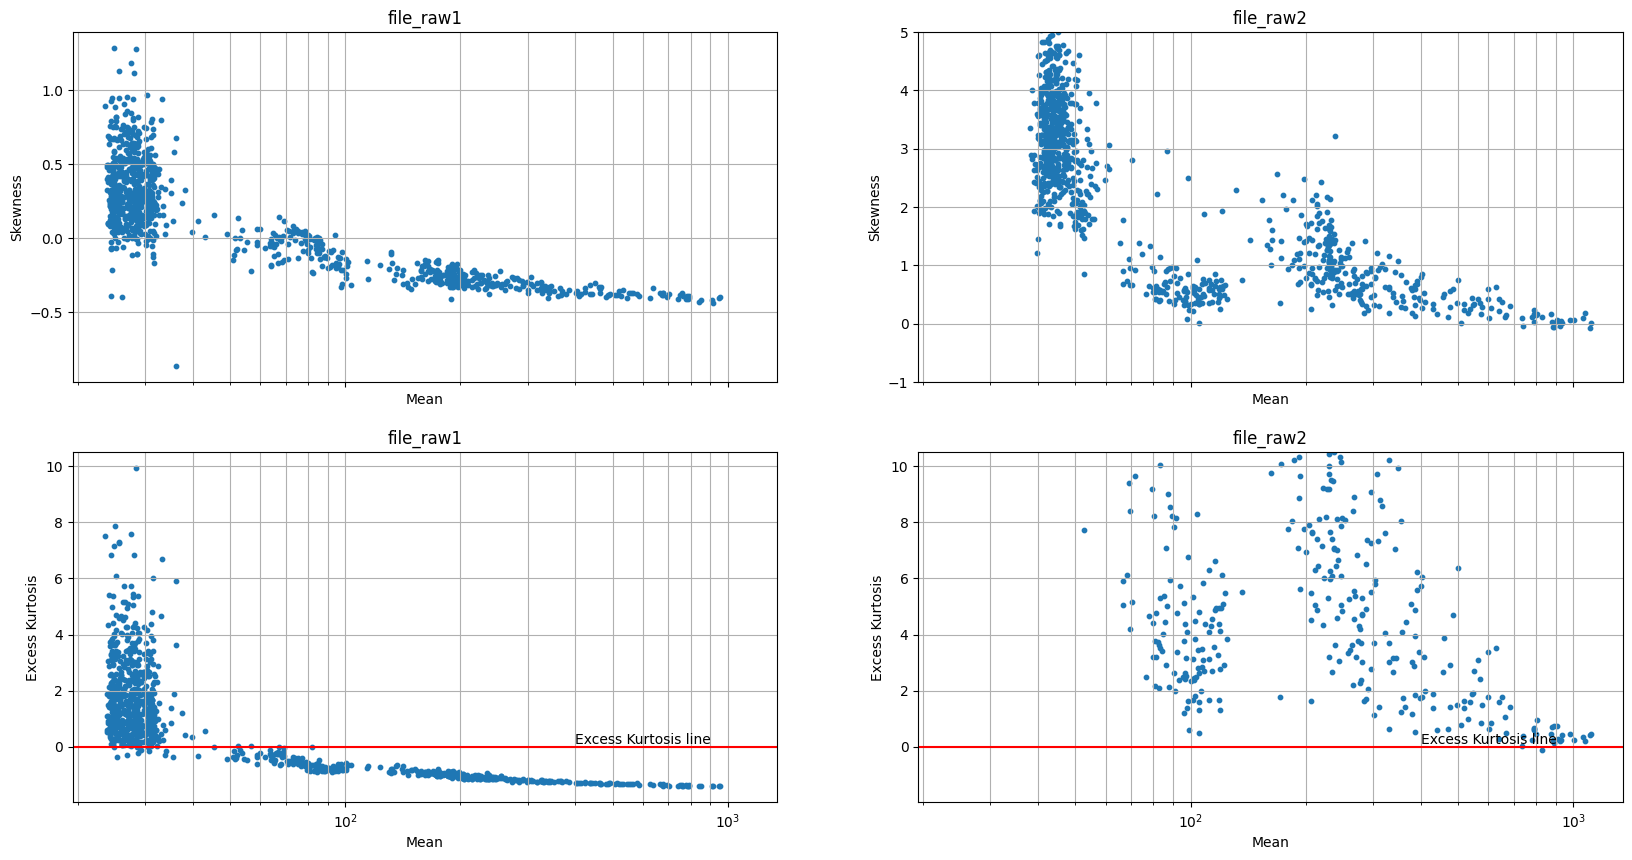

In [92]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_raw, y=skew_raw, alpha=1, s=10)
axes[0,0].set_xlabel('Mean')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('file_raw1')
axes[0,0].grid(visible=True, which='both', axis='both')
axes[0,0].set_xscale('log')

axes[0,1].scatter(x=mean_raw2, y=skew_raw2, alpha=1, s=10)
axes[0,1].set_xlabel('Mean')
axes[0,1].set_ylabel('Skewness')
axes[0,1].set_title('file_raw2')
axes[0,1].grid(visible=True, which='both', axis='both')
axes[0,1].set_ylim([-1,5])
# axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=mean_raw, y=kurt_raw-3, alpha=1, s=10)
axes[1,0].set_xlabel('Mean')
axes[1,0].set_ylabel('Excess Kurtosis')
axes[1,0].set_title('file_raw1')
axes[1,0].grid(visible=True, which='both', axis='both')
axes[1,0].axhline(y=0, color='r', linestyle='-')
axes[1,0].annotate('Excess Kurtosis line', (400,0.1))
# axes[1,0].set_ylim([-1.5,1.5])
axes[1,0].set_xscale('log')
# axes[1,0].set_xlim([400,1000])

axes[1,1].scatter(x=mean_raw2, y=kurt_raw2-3, alpha=1, s=10)
axes[1,1].set_xlabel('Mean')
axes[1,1].set_ylabel('Excess Kurtosis')
axes[1,1].set_title('file_raw2')
axes[1,1].grid(visible=True, which='both', axis='both')
axes[1,1].axhline(y=0, color='r', linestyle='-')
axes[1,1].annotate('Excess Kurtosis line', (400,0.1))
axes[1,1].sharey(axes[1,0])

plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 650))
axes = fig.subplots(475, 1, sharex=True)
for i in range(475):
    axes[i].hist( ds_raw2.isel(wave_number=i), bins=150)
    axes[i].set_title(f'Point number {i}: {ds_raw.wave_number[i].values} cm-1')
    axes[i].set_xlabel('Intensity')
    axes[i].set_ylabel('Counts')
plt.show()

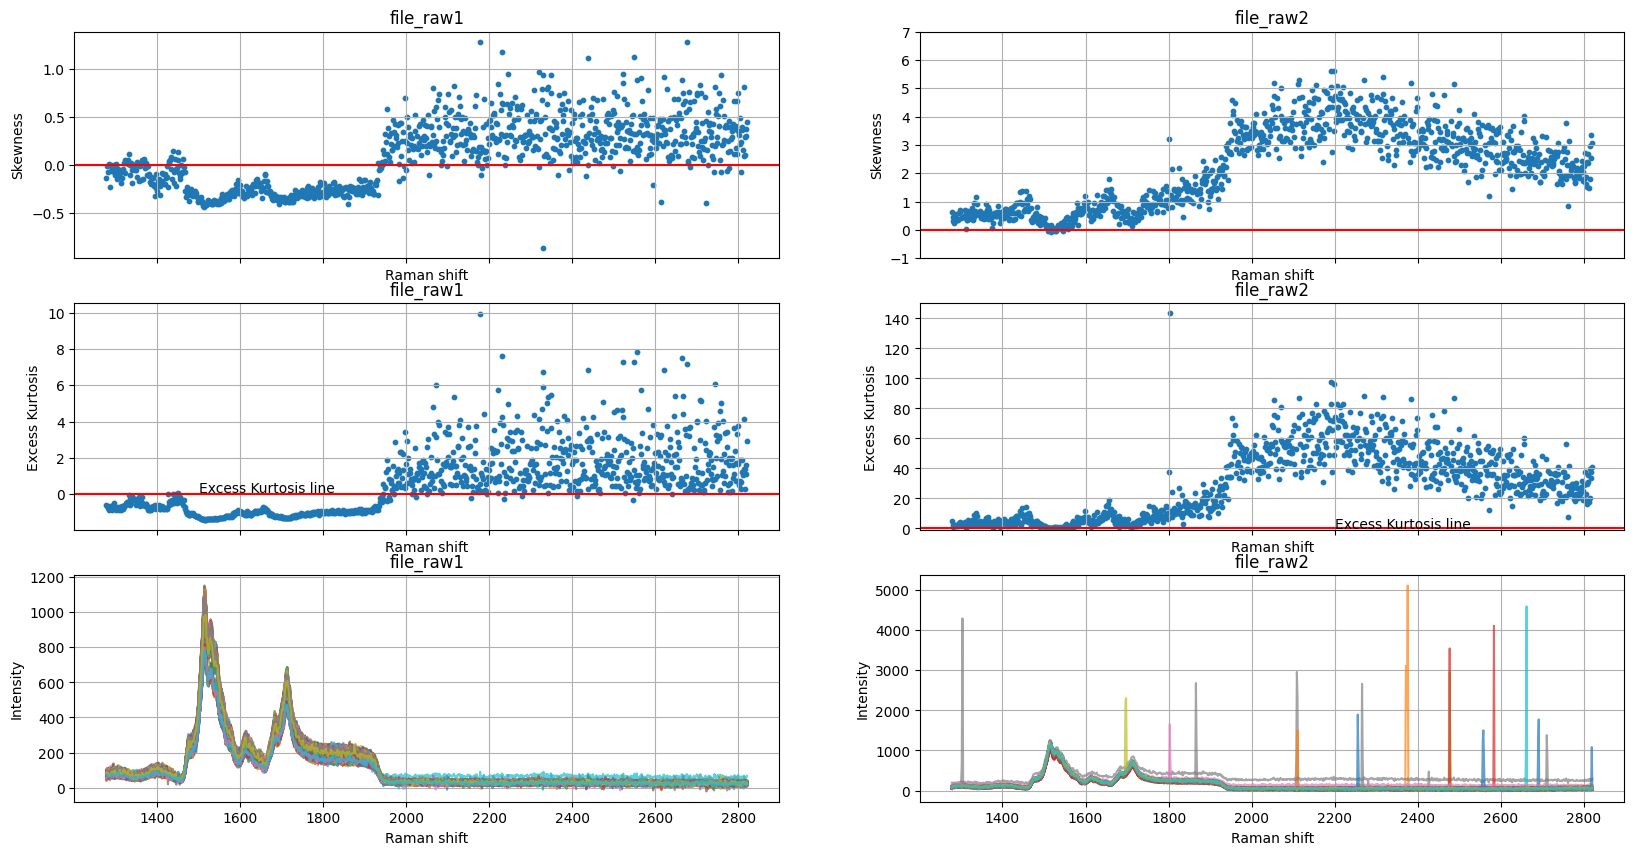

In [105]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(3, 2, sharex=True)

axes[0,0].scatter(x=ds_raw['wave_number'], y=skew_raw, alpha=1, s=10)
axes[0,0].set_xlabel('Raman shift')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('file_raw1')
axes[0,0].grid(visible=True, which='both', axis='both')
axes[0,0].axhline(y=0, color='r', linestyle='-')
# axes[0,0].set_xscale('log')

axes[0,1].scatter(x=ds_raw2['wave_number'], y=skew_raw2, alpha=1, s=10)
axes[0,1].set_xlabel('Raman shift')
axes[0,1].set_ylabel('Skewness')
axes[0,1].set_title('file_raw2')
axes[0,1].grid(visible=True, which='both', axis='both')
axes[0,1].axhline(y=0, color='r', linestyle='-')
axes[0,1].set_ylim([-1,7])
# axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=ds_raw['wave_number'], y=kurt_raw-3, alpha=1, s=10)
axes[1,0].set_xlabel('Raman shift')
axes[1,0].set_ylabel('Excess Kurtosis')
axes[1,0].set_title('file_raw1')
axes[1,0].grid(visible=True, which='both', axis='both')
axes[1,0].axhline(y=0, color='r', linestyle='-')
axes[1,0].annotate('Excess Kurtosis line', (1500,0.1))
# axes[1,0].set_ylim([-1.5,1.5])
# axes[1,0].set_xscale('log')
# axes[1,0].set_xlim([400,1000])

axes[1,1].scatter(x=ds_raw2['wave_number'], y=kurt_raw2-3, alpha=1, s=10)
axes[1,1].set_xlabel('Raman shift')
axes[1,1].set_ylabel('Excess Kurtosis')
axes[1,1].set_title('file_raw2')
axes[1,1].grid(visible=True, which='both', axis='both')
axes[1,1].axhline(y=0, color='r', linestyle='-')
axes[1,1].annotate('Excess Kurtosis line', (2200,0.1))
# axes[1,1].sharey(axes[1,0])
axes[1,1].set_ylim([-1,150])

for i in range(ds_raw.spectra.size):
    axes[2,0].plot(ds_raw["wave_number"], ds_raw.isel(spectra=i), alpha=0.7)
axes[2,0].set_xlabel('Raman shift')
axes[2,0].set_ylabel('Intensity')
axes[2,0].set_title('file_raw1')
axes[2,0].grid(visible=True, which='both', axis='both')

for i in range(ds_raw2.spectra.size):
    axes[2,1].plot(ds_raw2["wave_number"], ds_raw2.isel(spectra=i), alpha=0.7)
axes[2,1].set_xlabel('Raman shift')
axes[2,1].set_ylabel('Intensity')
axes[2,1].set_title('file_raw2')
axes[2,1].grid(visible=True, which='both', axis='both')

plt.show()